In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("../data/week1_features.csv")
df.columns = df.columns.str.replace('[', '_', regex=False).str.replace(']', '_', regex=False).str.replace(' ', '_', regex=False)

feature_cols = [col for col in df.columns if 'roll' in col]
X = df[feature_cols]
y = df["Machine_failure"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

model = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
model.fit(X_res, y_res)
print("Model trained!")

Model trained!


FileNotFoundError: [Errno 2] No such file or directory: '../reports/feature_importance.png'

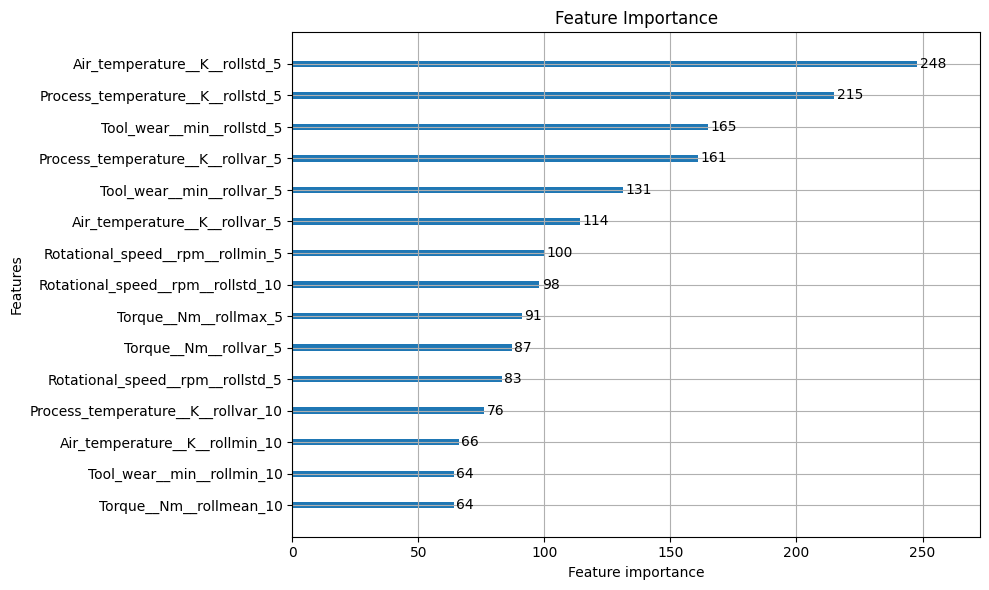

In [3]:
lgb.plot_importance(model, max_num_features=15, figsize=(10, 6))
plt.title("Feature Importance")
plt.tight_layout()
plt.savefig("../reports/feature_importance.png")
plt.show()
print("Saved: feature_importance.png ✅")

FileNotFoundError: [Errno 2] No such file or directory: '../reports/confusion_matrix.png'

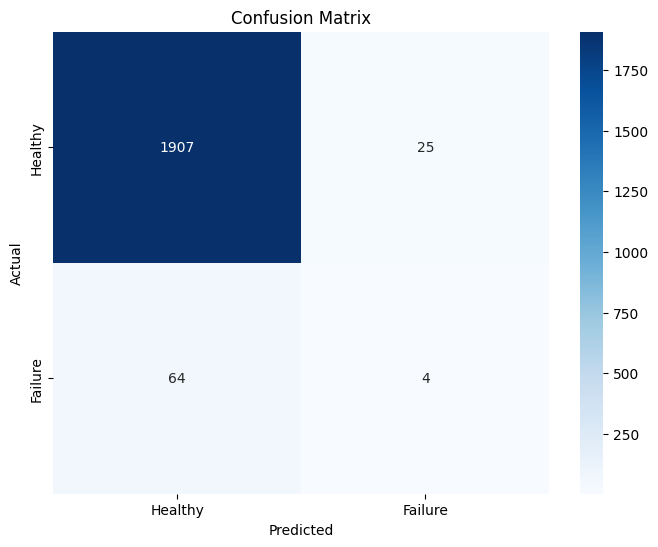

In [4]:
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Healthy", "Failure"],
            yticklabels=["Healthy", "Failure"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../reports/confusion_matrix.png")
plt.show()
print("Saved: confusion_matrix.png ✅")

FileNotFoundError: [Errno 2] No such file or directory: '../reports/roc_curve.png'

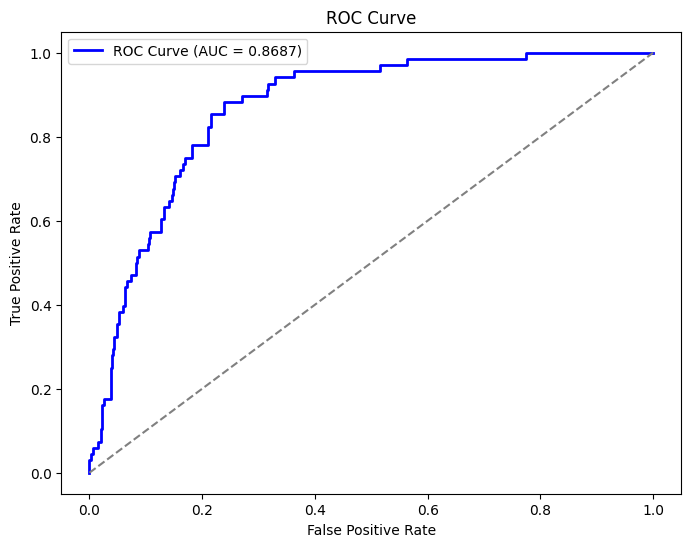

In [5]:
y_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("../reports/roc_curve.png")
plt.show()
print("Saved: roc_curve.png ✅")

FileNotFoundError: [Errno 2] No such file or directory: '../reports/precision_recall_curve.png'

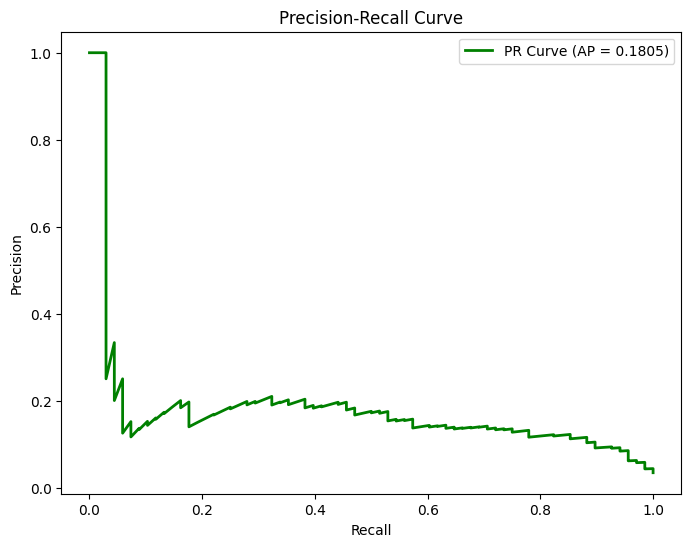

In [6]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', lw=2, label=f'PR Curve (AP = {ap:.4f})')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.savefig("../reports/precision_recall_curve.png")
plt.show()
print("Saved: precision_recall_curve.png ✅")

In [7]:
print("All charts saved in reports/ folder!")

All charts saved in reports/ folder!
